# Problem 4: Regularization

In [3]:
import numpy as np
import matplotlib.pyplot as plt

Let us generate and plot a dataset based on  

$$
y(x) = e^{3x}\dfrac{\sin(3\pi^2(x-0.5))}{3\pi^2(x-0.5)}
$$

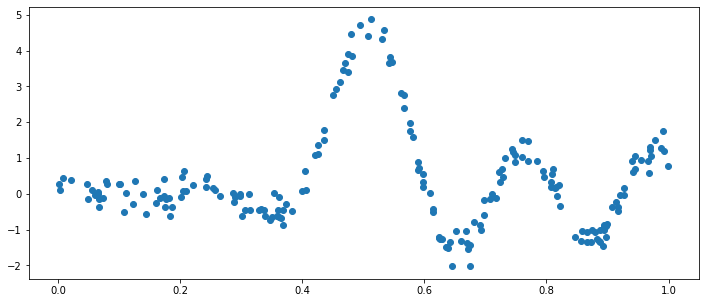

In [4]:
m = 200
x = np.random.rand(m)

num = np.sin(3*np.pi**2*(x-0.5)) # numerator
den = 3*np.pi**2*(x-0.5) # denominator
y = np.exp(3*x)*num/den + 0.25*np.random.randn(m) # function + noise

plt.figure(figsize=(12,5))
plt.plot(x,y,'o')

## Part 1

Fit a polynomial to the datapoints (do not regularize your polynomial model).
Explain how you selected the degree of the fitted polynomial.

In [9]:
# your code here
def build_poly_features(X,degree=1):
    from itertools import combinations_with_replacement as combwr
    from itertools import chain
    
    # number of data points (rows), number of features (columns)
    
    try:
        m,n = X.shape # will not work when x is a vector
    except:
        m = len(X)
        n = 1
        X = X.reshape(m,1)
    
    # number of polynomial features
    
    combinations = chain.from_iterable(combwr(range(n), i) for i in range(degree + 1))
    n_poly = sum(1 for combination in combinations)
    
    # polynomial feature matrix
    combinations = chain.from_iterable(combwr(range(n), i) for i in range(degree + 1))
    X_poly = np.ones((m,n_poly))
    for column_index, combination in enumerate(combinations):
        X_poly[:,column_index] = np.product(X[:,combination],axis = 1)
        
    return X_poly

I seem to be able to count at least seven local extrema in the plot, so I know I want my polynomial to high enough degree to have at least seven local extrema. 10 seemed like a good round number that was slightly bigger than 8 (the lowest degree of a polynomial with 7 local extrema).

In [15]:
d=10

X_poly = build_poly_features(x,degree=d)
theta = np.linalg.lstsq(X_poly,y,rcond=None)[0]

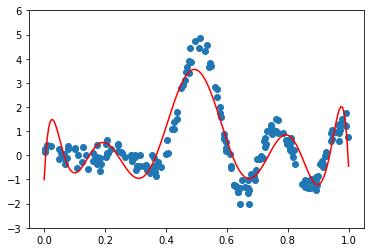

In [16]:
m_plot = 200
x_plot = np.linspace(0,1,m_plot)

x_plot_poly = build_poly_features(x_plot,degree=d)
y_plot = x_plot_poly.dot(theta.T)

plt.ylim([-3,6])

plt.scatter(x,y)
plt.plot(x_plot,y_plot,color='red')

## Part 2

Fit a degree-100 polynomial to the datapoints. But this time add a regularization term. Explain how you selected the regularization constant.

In [1]:
# you code here - I ripped this code from your GitHub actually, my code from class wouldn't run :(

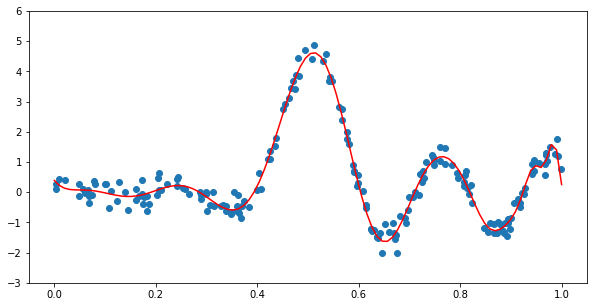

In [37]:
d = 100 # degree
C = 1e-15 # regularization constant


# feature matrices
X_poly = build_poly_features(x,degree=d)
    
# solve regularized least squares problem'
theta = np.linalg.solve(X_poly.T.dot(X_poly)+C*np.identity(d+1), X_poly.T.dot(y))

# plot datapoints 
plt.figure(figsize=(10,5))
plt.scatter(x,y,)
plt.ylim([-3,6])

# plot fitted model   
m_plot = 100  
x_plot = np.linspace(0,1,m_plot) 
X_plot_poly = build_poly_features(x_plot,degree=d)
y_plot = X_plot_poly.dot(theta)
plt.plot(x_plot,y_plot,'r',label='fitted model')

****
Below is an experiment in which we test 20 powers of 10 as possible regularization constants. We graph the mse associated with each regularization constant, and choose the regularization constant leading to the smallest mse. 

In [32]:
degree = 100
C_list = 10.0**(np.arange(-20,1)) # regularization constants

mse = np.zeros(len(C_list))
for i,C in enumerate(C_list): #(0,1e-16), (1,1e-15), (2,1e-14), ...
    # build feature matrices
    X_poly = build_poly_features(x,degree=d)

    # solve regularized least squares problem'
    theta = np.linalg.solve(X_poly.T.dot(X_poly)+C*np.identity(d+1), X_poly.T.dot(y))
    
    # mean squared errors
    y_pred = X_poly.dot(theta)
    mse[i] = np.mean((y-y_pred)**2)

Text(0.5, 0, 'regularization constant')

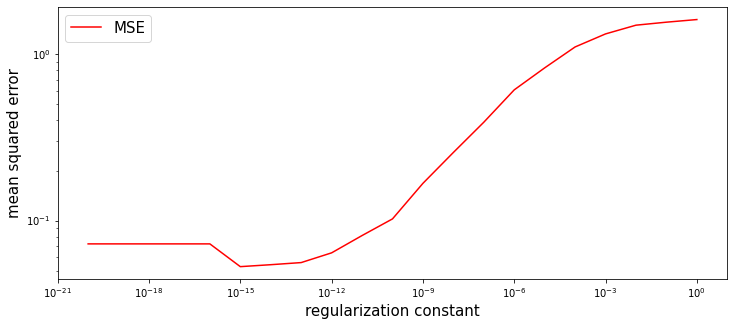

In [33]:
plt.figure(figsize=(12,5))
plt.loglog(C_list,mse,'r-',label='MSE') 
plt.legend(fontsize = 15)
plt.ylabel('mean squared error', fontsize=15)
plt.xlabel('regularization constant', fontsize=15)

In [36]:
C_list[np.argmin(mse)]

1e-15